In [ ]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
#If you've made changes to the helper script (helper.py), this will reload the module so your changes take effect without restarting the notebook.
import preparations as prep # dataset loading and definitions
import helper as hlp # helper functions for plotting and image processing
import importlib
importlib.reload(hlp)
importlib.reload(prep)

<module 'helper' from '/content/helper.py'>

In [ ]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf #These are the basic blocks to build and train neural networks using TensorFlow/Keras.
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping #stops training if validation doesn't improve after a while.
from tensorflow.keras.callbacks import ReduceLROnPlateau #lowers learning rate if training gets stuck.

# Reporting t
#These tools print how good your model is:
from sklearn.metrics import classification_report #Precision, Recall, F1 score, etc.
from sklearn.metrics import confusion_matrix 
from imblearn.metrics import classification_report_imbalanced #is better when you have imbalanced classes.

# Imports for visualizations
#These libraries help you draw plots.
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Transfer Learning

##### Dataset loading and preprocessing

In [3]:
# List available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("✅ TensorFlow is using a GPU:")
    for gpu in gpus:
        print("  -", gpu)
else:
    print("❌ No GPU detected. TensorFlow is using the CPU.")

✅ TensorFlow is using a GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# Load the original dataset, if not done yet
prep.download_and_move_dataset() #Downloads the dataset (if not already present).
#It organizes the data into folders by class (COVID, Lung Opacity, etc.).

In [ ]:
# Read in the images
train_ds, val_ds, class_names = hlp.read_only_xray_images() #Loads the X-ray images and resizes them (usually to 224x224 for VGG16).
#Splits the data: train_ds: used for training, val_ds: used for validation, class_names: contains the names of the disease classes


Created empty directory: /tmp_93974692
Made directory: /tmp_93974692/Lung_Opacity/
Moved /COVID-19_Radiography_Dataset/Lung_Opacity/masks to /tmp_93974692/Lung_Opacity/masks
Made directory: /tmp_93974692/Viral Pneumonia/
Moved /COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /tmp_93974692/Viral Pneumonia/masks
Made directory: /tmp_93974692/COVID/
Moved /COVID-19_Radiography_Dataset/COVID/masks to /tmp_93974692/COVID/masks
Made directory: /tmp_93974692/Normal/
Moved /COVID-19_Radiography_Dataset/Normal/masks to /tmp_93974692/Normal/masks
Found 21165 files belonging to 4 classes.
Using 16932 files for training.
Using 4233 files for validation.
Found classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train dataset batch: (32, 224, 224, 3) (32,)
Labels [1 1 2 2 2 2 1 2 2 2 0 2 1 2 2 2 0 2 0 2 0 1 1 1 2 1 2 1 2 2 0 2]
Validation dataset batch: (32, 224, 224, 3) (32,)
Labels [1 2 1 1 0 2 2 3 1 2 0 2 2 2 1 2 1 2 3 2 2 2 0 2 2 0 1 1 3 2 0 1]
Moved /tmp_93974692/Lung_Opacity/

In [ ]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())
#Prints the number of batches (small groups of images) in training and validation datasets.

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1): #For VGG16, input shape should be: (32, 224, 224, 3) → 32 color images of size 224x224
    print('Batch shape:', images.shape, labels.shape) #Checks the format of one batch.
    # Show some sample image shapes and according labels (should be shuffled!)
    for image, label in zip(images.numpy(),labels.numpy()): #Prints each image shape and label from that batch.
        print(image.shape, label) #Helps confirm everything is in the correct format before feeding into VGG16.



Number of batch in train_ds: 530
Number of batch in val_ds: 133
Batch shape: (32, 224, 224, 3) (32,)
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0


In [ ]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter #Imports a tool to count items in a list (how many images per class).

# Count occurrences of each class
#Goes through the entire training set and counts how many images belong to each class.
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

#Creates a dictionary of weights to give more importance to underrepresented classes during training.
class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Viral Pneumonia': 1048, 'Lung_Opacity': 4847, 'Normal': 8134, 'COVID': 2903}
Class Weights: {np.int32(3): 4.03912213740458, np.int32(1): 0.8733237053847741, np.int32(2): 0.5204081632653061, np.int32(0): 1.4581467447468137}


In [ ]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input
#Imports the preprocessing function specific to VGG16.
#VGG16 expects input in a specific format:
#RGB images with pixel values in a certain range.
#This function ensures that the images match what VGG16 was originally trained on (ImageNet).

# We apply preprocessing now in the model itself, so there will be no further need, when later the model is used on raw images
#train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
#val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
#These lines (currently commented) apply preprocessing to every image and label pair.
#They normalize the pixel values to match what VGG16 expects.

#### Try with VGG16 (imagenet pretrained)

In [ ]:
# Make sure, the models folder exists
if not os.path.exists(os.path.join('..', 'models')): #Checks whether a folder called models exists. If not, it creates it.
    os.makedirs(os.path.join('..', 'models')) #This is where your trained model will be saved.

# This model name for saving and loading
model_name = os.path.join('..', 'models', '4_preproc_vgg16retrained_dense128.keras') #Sets a custom file path for saving the final model.
#dense128 in the name means: the model ends with a dense layer with 128 neurons.

In [ ]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16 #VGG16 is a famous image classification model trained on ImageNet (millions of images).
#We're going to reuse its learned features for our X-ray classification task.



# VGG16 model - Loads VGG16 with pretrained weights.
base_model = VGG16(weights='imagenet', include_top=False) #include_top=False removes the last classification layer, so we can add our own.
#The remaining layers are used as a feature extractor.

# Let the layers of the base model retrain, starting from the pretrained weights
base_model.trainable = True #Allows all layers of VGG16 to be updated during training.
#This is called fine-tuning → useful for medical images that are different from ImageNet.

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3)) ## Input size for VGG16

# Preprocess the image 
x = preprocess_input(inputs) # Apply preprocessing from VGG16

# Build the model
x = base_model(x)  ## Pass input through VGG16
x = GlobalAveragePooling2D()(x)  # Flatten features (no full Dense layer yet)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(128, activation='relu')(x) # was before 512, let's see, if 128 performs better
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)
#Input: RGB image (224x224) as required by VGG16.
#GlobalAveragePooling2D: Reduces spatial features to a single vector.
#Adds two Dense layers (1024 + 128 neurons) with ReLU and Dropout to avoid overfitting.
#Final layer uses softmax for multi-class classification (4 classes: COVID, Lung Opacity, etc.).

vgg16 = Model(inputs=inputs, outputs=outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Applied Callbacks
early_stopping = EarlyStopping( #Stops training early if validation loss doesn't improve after 5 epochs.
                                patience=5, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 5 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss') #Prevents overfitting and saves training time.

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau( #If model gets stuck (val_loss stops improving), learning rate is reduced to fine-tune better.
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [ ]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
#optimizer="adam": A popular and effective optimizer that adjusts learning rate automatically.
#loss="sparse_categorical_crossentropy": Used for multi-class classification when your labels are integers (not one-hot encoded).
#metrics=["accuracy"]: Tells the model to track accuracy during training.

#Prints a text summary of your model: layers, output shapes, parameters.
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
df_summary = hlp.model_summary_to_df(vgg16) #Converts the model layout into a pandas DataFrame (easier to copy, export, or view).
display(df_summary) #Helpful for documentation or analysis.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item (GetItem)        │ (None, 224, 224)       │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_1 (GetItem)      │ (None, 224, 224)       │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_2 (GetItem)      │ (None, 224, 224)       │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack (Stack)             │ (None, 224, 224, 3)    │              0 │ get_item[0][0],        │
│                           │                        │                │ get_item_1[0][0],      │
│                           │                        │                │ get_item_2[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 224, 224, 3)    │              0 │ stack[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 7, 7, 512)      │     14,714,688 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 1024)           │        525,312 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 1024)           │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 128)            │        131,200 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 4)              │            516 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 15,371,716 (58.64 MB)

 Trainable params: 15,371,716 (58.64 MB)

 Non-trainable params: 0 (0.00 B)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1,"(None, 224, 224, 3)",-
1,(InputLayer),,
2,get_item (GetItem),"(None, 224, 224)",input_layer_1[0][0]
3,get_item_1 (GetItem),"(None, 224, 224)",input_layer_1[0][0]
4,get_item_2 (GetItem),"(None, 224, 224)",input_layer_1[0][0]
5,stack (Stack),"(None, 224, 224, 3)","get_item[0][0],"
6,,,"get_item_1[0][0],"
7,,,get_item_2[0][0]
8,add (Add),"(None, 224, 224, 3)",stack[0][0]
9,vgg16 (Functional),"(None, 7, 7, 512)",add[0][0]


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds, #train_ds: training dataset
                          epochs=25, #the model will go through the data up to 25 times
                          validation_data=val_ds, #test performance during training
                          class_weight=class_weights_dict, #handles imbalanced classes
                          callbacks=[early_stopping, reduce_learning_rate]) #stop early if it’s not improving or lower learning rate when stuck
#In practice, early stopping kicked in before all 25 epochs were reached.

Epoch 1/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 67s 87ms/step - accuracy: 0.2553 - loss: 1.8712 - val_accuracy: 0.5660 - val_loss: 1.0861 - learning_rate: 0.0010
Epoch 2/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.5365 - loss: 0.8748 - val_accuracy: 0.7737 - val_loss: 0.6590 - learning_rate: 0.0010
Epoch 3/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.7349 - loss: 0.5682 - val_accuracy: 0.8063 - val_loss: 0.5080 - learning_rate: 0.0010
Epoch 4/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.7909 - loss: 0.4349 - val_accuracy: 0.8597 - val_loss: 0.3844 - learning_rate: 0.0010
Epoch 5/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.8223 - loss: 0.3657 - val_accuracy: 0.8063 - val_loss: 0.5561 - learning_rate: 0.0010
Epoch 6/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 59ms/step - accuracy: 0.8350 - loss: 0.3450 - val_accuracy: 0.8703 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 7/25
530/530 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.8663 - l

In [ ]:
# Save the model for potential later use
vgg16.save(model_name) #Stores the trained model to disk so it can be reused later (no retraining needed).

#Left Plot: Model Loss by Epoch
#-Shows how the training and validation errors decreased
#-Lower loss = better performance
#-If the orange line (test) goes up while blue (train) goes down → overfitting!

#Right Plot: Model Accuracy by Epoch
#-Blue = training accuracy, orange = validation accuracy
#-Model converges around 90–95% accuracy, which is strong


##### Evalution

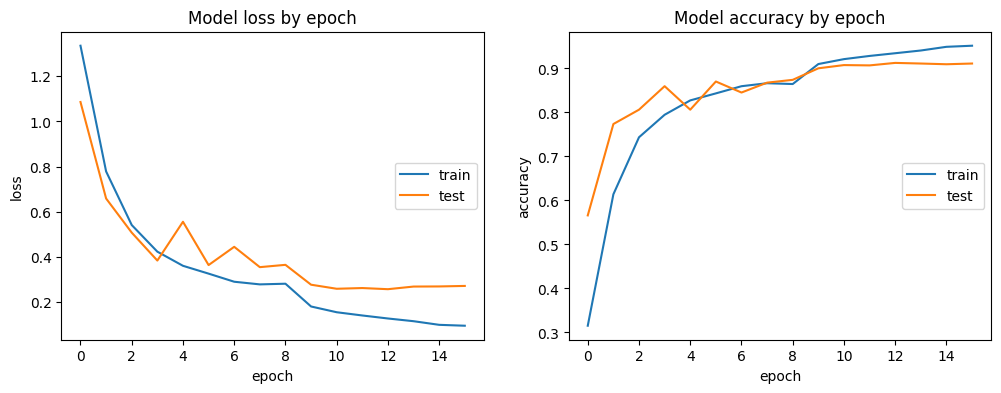

In [ ]:
hlp.plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.


#Slight mismatch: The training accuracy goes up to ~95%, and validation stays around ~85–90%.

In [ ]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)
#Loads the previously saved VGG16 model from disk.
#Useful if you're continuing work after restarting the notebook.

In [ ]:
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = hlp.get_predictions_and_labels(vgg16, val_ds)
#Runs the model on the validation dataset.
#Returns: y_true: the correct class labels, y_pred: the predicted labels from the model

,pre,rec,spe,f1,geo,iba,sup
COVID,0.950139,0.962132,0.989773,0.956098,0.975854,0.949660,713.000000
Lung_Opacity,0.851064,0.892704,0.940678,0.871387,0.916377,0.835718,1165.000000
Normal,0.930514,0.897959,0.936552,0.913947,0.917052,0.837740,2058.000000
Viral Pneumonia,0.933993,0.952862,0.994919,0.943333,0.973663,0.944033,297.000000
avg_pre,0.912197,0.912197,0.912197,0.912197,0.912197,0.912197,0.912197
avg_rec,0.911174,0.911174,0.911174,0.911174,0.911174,0.911174,0.911174
avg_spe,0.950747,0.950747,0.950747,0.950747,0.950747,0.950747,0.950747
avg_f1,0.911395,0.911395,0.911395,0.911395,0.911395,0.911395,0.911395
avg_geo,0.930743,0.930743,0.930743,0.930743,0.930743,0.930743,0.930743
avg_iba,0.863493,0.863493,0.863493,0.863493,0.863493,0.863493,0.863493


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,686,11,12,4
Lung_Opacity,11,1040,114,0
Normal,23,171,1848,16
Viral Pneumonia,2,0,12,283


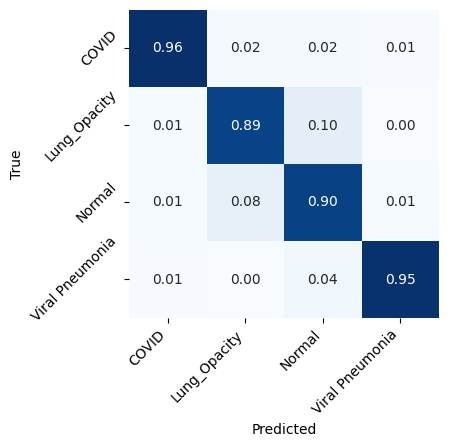

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID              686            11      12                4
 Lung_Opacity        11          1040     114                0
 Normal              23           171    1848               16
 Viral Pneumonia      2             0      12              283,
 'classification_report':                          pre          rec          spe           f1  \
 COVID               0.950139     0.962132     0.989773     0.956098   
 Lung_Opacity        0.851064     0.892704     0.940678     0.871387   
 Normal              0.930514     0.897959     0.936552     0.913947   
 Viral Pneumonia     0.933993     0.952862     0.994919     0.943333   
 avg_pre             0.912197     0.912197     0.912197     0.912197   
 avg_rec             0.911174     0.911174     0.911174     0.911174   
 avg_spe             0.950747     0.950747     0.950747     0.950747   
 avg_f1              0.911395     0.911395     0.911395     0.911395   

In [ ]:
hlp.report_model_performance(y_true, y_pred, class_names)
#This helper shows: Metrics Table (Per Class)
# Conclusion: Our model predicts the 4 classes really well
# High values across the board (most > 0.85), especially for COVID and Normal – great performance!